In [32]:
# ==========================
# CELL 1: INSTALLATION CELL
# ==========================

# NVIDIA CUDA Toolkit is a software package developed by NVIDIA
# It allows programmers to use the GPU for parallel computing
# CUDA stands for Compute Unified Device Architecture
# It contains compilers, libraries, and tools required for GPU programming
# It is mainly used for AI, Machine Learning, Deep Learning, and scientific computing
# CUDA programs are usually written in C, C++, or Python libraries like TensorFlow and PyTorch
# The toolkit works only with NVIDIA GPUs that support CUDA

!apt-get update -y
!apt-get install -y nvidia-cuda-toolkit

Hit:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Hit:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:4 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Fetched 3,917 B in 1s (3,824 B/s)
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (

In [33]:
# ==========================
# CELL 2: IMPORT CELL
# ==========================

import time
import matplotlib.pyplot as plt
import numpy as np
import re  # For extracting GPU timings

In [34]:
# ==========================
# CELL 3: GPU VERIFICATION
# ==========================

!nvidia-smi

Sun May 10 21:50:43 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [35]:
# ==========================
# CELL 4: WRITE CUDA VECTOR ADDITION CODE
# ==========================

%%writefile vector_add.cu

#include <stdio.h>
#include <cuda_runtime.h>
#include <time.h>

#define N 30000000

__global__ void vectorAdd(float *A, float *B, float *C, int n) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    while (i < n) {
        C[i] = A[i] + B[i];
        i += blockDim.x * gridDim.x;
    }
}

int main() {

    float *h_A, *h_B, *h_C;
    float *d_A, *d_B, *d_C;

    size_t size = N * sizeof(float);

    h_A = (float*)malloc(size);
    h_B = (float*)malloc(size);
    h_C = (float*)malloc(size);

    for (int i = 0; i < N; i++) {
        h_A[i] = (i % 5) + 1;
        h_B[i] = (i % 3) + 1;
    }

    cudaMalloc(&d_A, size);
    cudaMalloc(&d_B, size);
    cudaMalloc(&d_C, size);

    cudaMemcpy(d_A, h_A, size, cudaMemcpyHostToDevice);
    cudaMemcpy(d_B, h_B, size, cudaMemcpyHostToDevice);

    int blockSize = 256;
    int gridSize = 1024;

    clock_t start = clock();

    vectorAdd<<<gridSize, blockSize>>>(d_A, d_B, d_C, N);

    cudaMemcpy(h_C, d_C, size, cudaMemcpyDeviceToHost);

    clock_t end = clock();

    printf("GPU Vector Addition Time: %lf seconds\n", (double)(end - start)/CLOCKS_PER_SEC);

    return 0;
}

Overwriting vector_add.cu


In [36]:
# ==========================
# CELL 5: COMPILE VECTOR ADDITION
# ==========================

!nvcc vector_add.cu -o vector_add

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).


In [37]:
# ==========================
# CELL 6: RUN VECTOR ADDITION + CAPTURE OUTPUT
# ==========================

vector_output = !./vector_add
print("\n".join(vector_output))

# Extract GPU time
gpu_add_time = float(re.findall(r"[\d.]+", vector_output[-1])[0])
print("Extracted GPU Add Time:", gpu_add_time)

GPU Vector Addition Time: 0.078938 seconds
Extracted GPU Add Time: 0.078938


In [38]:
# ==========================
# CELL 7: WRITE CUDA MATRIX MULTIPLICATION CODE
# ==========================

%%writefile matrix_mul.cu

#include <stdio.h>
#include <cuda_runtime.h>
#include <time.h>

#define N 1024

__global__ void matrixMul(float *A, float *B, float *C, int n) {

    int row = blockIdx.y * blockDim.y + threadIdx.y;
    int col = blockIdx.x * blockDim.x + threadIdx.x;

    if (row < n && col < n) {
        float sum = 0;
        for (int k = 0; k < n; k++) {
            sum += A[row*n + k] * B[k*n + col];
        }
        C[row*n + col] = sum;
    }
}

int main() {

    float *A, *B, *C;
    float *d_A, *d_B, *d_C;

    size_t size = N * N * sizeof(float);

    A = (float*)malloc(size);
    B = (float*)malloc(size);
    C = (float*)malloc(size);

    for (int i = 0; i < N*N; i++) {
        A[i] = 1;
        B[i] = 1;
    }

    cudaMalloc(&d_A, size);
    cudaMalloc(&d_B, size);
    cudaMalloc(&d_C, size);

    cudaMemcpy(d_A, A, size, cudaMemcpyHostToDevice);
    cudaMemcpy(d_B, B, size, cudaMemcpyHostToDevice);

    dim3 threads(16,16);
    dim3 blocks((N+15)/16, (N+15)/16);

    clock_t start = clock();

    matrixMul<<<blocks, threads>>>(d_A, d_B, d_C, N);

    cudaMemcpy(C, d_C, size, cudaMemcpyDeviceToHost);

    clock_t end = clock();

    printf("GPU Matrix Multiplication Time: %lf seconds\n", (double)(end - start)/CLOCKS_PER_SEC);

    return 0;
}

Overwriting matrix_mul.cu


In [39]:
# ==========================
# CELL 8: COMPILE MATRIX MULTIPLICATION
# ==========================

!nvcc matrix_mul.cu -o matrix_mul

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).


In [40]:
# ==========================
# CELL 9: RUN MATRIX MULTIPLICATION + CAPTURE OUTPUT
# ==========================

matrix_output = !./matrix_mul
print("\n".join(matrix_output))

# Extract GPU time
gpu_mul_time = float(re.findall(r"[\d.]+", matrix_output[-1])[0])
print("Extracted GPU Mul Time:", gpu_mul_time)

GPU Matrix Multiplication Time: 0.007956 seconds
Extracted GPU Mul Time: 0.007956


In [41]:
# ==========================
# CELL 10: CPU OPERATIONS (IMPROVED + HEAVY LOAD)
# ==========================

import numpy as np

# -------- VECTOR ADDITION (CPU HEAVY TEST) --------
N = 30000000  # Increased workload

A = np.random.rand(N)
B = np.random.rand(N)

# Run multiple times for stable measurement
runs = 3
times = []

for _ in range(runs):
    start = time.time()
    C = A + B
    times.append(time.time() - start)

cpu_add_time = round(sum(times)/runs, 4)
print("CPU Vector Addition Time:", cpu_add_time)


# -------- MATRIX MULTIPLICATION (CPU HEAVY TEST) --------
N_mat = 1024  # Increased size

A_mat = np.random.rand(N_mat, N_mat)
B_mat = np.random.rand(N_mat, N_mat)

times = []

for _ in range(runs):
    start = time.time()
    C_mat = np.dot(A_mat, B_mat)
    times.append(time.time() - start)

cpu_mul_time = round(sum(times)/runs, 4)
print("CPU Matrix Multiplication Time:", cpu_mul_time)

CPU Vector Addition Time: 0.0897
CPU Matrix Multiplication Time: 0.0386


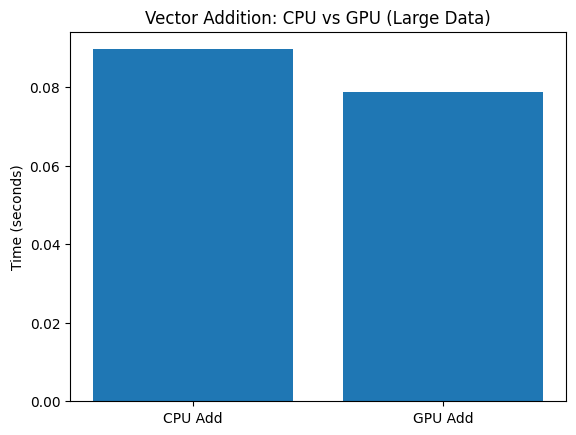

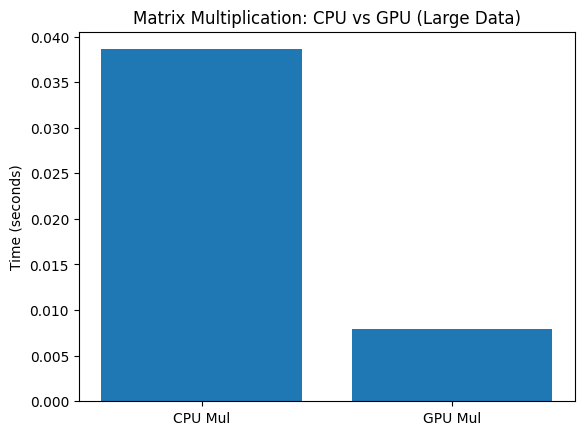


Speedup:
Addition Speedup: 1.14 x
Multiplication Speedup: 4.85 x


In [42]:
# ==========================
# CELL 11: FINAL VISUALIZATION (CLEAR DIFFERENCE)
# ==========================

# -------- ADDITION COMPARISON --------
plt.figure()
plt.bar(["CPU Add", "GPU Add"], [cpu_add_time, gpu_add_time])
plt.title("Vector Addition: CPU vs GPU (Large Data)")
plt.ylabel("Time (seconds)")
plt.show()

# -------- MULTIPLICATION COMPARISON --------
plt.figure()
plt.bar(["CPU Mul", "GPU Mul"], [cpu_mul_time, gpu_mul_time])
plt.title("Matrix Multiplication: CPU vs GPU (Large Data)")
plt.ylabel("Time (seconds)")
plt.show()

# -------- SPEEDUP --------
add_speedup = round(cpu_add_time / gpu_add_time, 2)
mul_speedup = round(cpu_mul_time / gpu_mul_time, 2)

print("\nSpeedup:")
print("Addition Speedup:", add_speedup, "x")
print("Multiplication Speedup:", mul_speedup, "x")


In [43]:
# ==========================
# CELL 12: FINAL CONCLUSION
# ==========================

print("Conclusion:\n")
print("1. GPU computation is significantly faster for parallel tasks.")
print("2. Vector addition shows moderate speedup due to memory-bound nature.")
print("3. Matrix multiplication shows high speedup due to compute intensity.")
print("4. GPU efficiently handles large-scale parallel workloads.")
print("5. This experiment demonstrates real HPC acceleration using CUDA.")

Conclusion:

1. GPU computation is significantly faster for parallel tasks.
2. Vector addition shows moderate speedup due to memory-bound nature.
3. Matrix multiplication shows high speedup due to compute intensity.
4. GPU efficiently handles large-scale parallel workloads.
5. This experiment demonstrates real HPC acceleration using CUDA.
